In [1]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

In [2]:
import pandas as pd

In [3]:
from pytorch_forecasting import TimeSeriesDataSet
from pytorch_forecasting.data import NaNLabelEncoder


In [4]:
future_df = pd.read_csv("future_features_dataset.csv")

In [5]:
train_df = pd.read_csv("forecast_dataset.csv")

In [6]:
train_df

,date,SKU,qty,price_per_unit,tavg,prcp,tsun,sale_active,sale_percent,mmdd,day_of_week,month,is_holiday
0,2024-01-26,9101dx,2.0,1522.660000,9.0,1.2,0.0,True,0.24,01-26,4,1,False
1,2024-01-27,9101dx,0.0,1295.228583,3.0,0.0,510.0,True,0.24,01-27,5,1,False
2,2024-01-28,9101dx,0.0,1295.228583,3.7,0.0,516.0,True,0.24,01-28,6,1,False
3,2024-01-29,9101dx,2.0,1449.580000,5.5,0.0,492.0,True,0.24,01-29,0,1,False
4,2024-01-30,9101dx,1.0,1449.580000,6.1,0.0,192.0,True,0.24,01-30,1,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
149851,2025-11-20,sz21032,0.0,74.790000,2.3,0.0,59.0,False,0.00,11-20,3,11,False
149852,2025-11-21,sz21032,0.0,74.790000,-1.0,0.0,136.0,False,0.00,11-21,4,11,False
149853,2025-11-22,sz21032,0.0,74.790000,-4.2,0.0,243.0,False,0.00,11-22,5,11,False
149854,2025-11-23,sz21032,0.0,74.790000,-2.6,2.5,155.0,False,0.00,11-23,6,11,False


In [7]:
future_df["date"] = pd.to_datetime(future_df["date"])
train_df["date"] = pd.to_datetime(train_df["date"])

In [8]:
train_df.sort_values(by="date", inplace=True)

In [9]:
train_df.reset_index(drop=True, inplace=True)

In [10]:
train_df

,date,SKU,qty,price_per_unit,tavg,prcp,tsun,sale_active,sale_percent,mmdd,day_of_week,month,is_holiday
0,2024-01-26,9101dx,2.0,1522.660000,9.0,1.2,0.0,True,0.24,01-26,4,1,False
1,2024-01-26,9202,2.0,277.830000,9.0,1.2,0.0,True,0.24,01-26,4,1,False
2,2024-01-26,92018,0.0,268.461739,9.0,1.2,0.0,False,0.00,01-26,4,1,False
3,2024-01-26,sw100183,0.0,48.320000,9.0,1.2,0.0,True,0.24,01-26,4,1,False
4,2024-01-26,92016,0.0,272.180000,9.0,1.2,0.0,False,0.00,01-26,4,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
149851,2025-11-24,ga10172,0.0,671.065714,4.1,5.8,0.0,True,0.20,11-24,0,11,False
149852,2025-11-24,ga10171,0.0,531.822741,4.1,5.8,0.0,True,0.20,11-24,0,11,False
149853,2025-11-24,ga1016sf,0.0,357.635000,4.1,5.8,0.0,True,0.20,11-24,0,11,False
149854,2025-11-24,ga10263,0.0,151.543413,4.1,5.8,0.0,False,0.00,11-24,0,11,False


In [11]:
import pandas as pd
from pytorch_forecasting import TimeSeriesDataSet

# make sure date is datetime
train_df["date"] = pd.to_datetime(train_df["date"])

# sort by group + time (recommended)
train_df = train_df.sort_values(["SKU", "date"])

# create integer time index: days since first date
train_df["time_idx"] = (train_df["date"] - train_df["date"].min()).dt.days.astype("int64")


In [12]:
train_df["SKU"] = train_df["SKU"].astype("category")

# make calendar features string-based, then categorical
train_df["month"] = train_df["month"].astype(str).astype("category")
train_df["day_of_week"] = train_df["day_of_week"].astype(str).astype("category")

# bool is treated as numeric -> convert to string labels
train_df["is_holiday"] = train_df["is_holiday"].map(
    {True: "holiday", False: "no_holiday"}
).astype("category")

In [13]:
train_df.dtypes

date              datetime64[ns]
SKU                     category
qty                      float64
price_per_unit           float64
tavg                     float64
prcp                     float64
tsun                     float64
sale_active                 bool
sale_percent             float64
mmdd                      object
day_of_week             category
month                   category
is_holiday              category
time_idx                   int64
dtype: object

In [14]:
max_encoder_length: int = 365
max_prediction_length: int = 100
min_encoder_length: int = 90
min_prediction_length: int = 30

In [15]:
from pytorch_forecasting.data.encoders import TorchNormalizer
# create the dataset for the training period
final_training_ds = TimeSeriesDataSet(
        train_df,
        time_idx="time_idx",
        target="qty",
        group_ids=["SKU"],
        static_categoricals=["SKU"],
        time_varying_known_reals=["price_per_unit", "tavg", "prcp", "tsun", "sale_percent"],
        time_varying_known_categoricals=["month", "day_of_week", "is_holiday"],
        time_varying_unknown_reals=["qty"],
        target_normalizer=TorchNormalizer(method="identity", center=False),
        max_encoder_length=max_encoder_length,
        max_prediction_length=max_prediction_length,
        min_encoder_length=min_encoder_length,
        min_prediction_length=min_prediction_length,
        # No explicit lags are passed here; the model can still learn patterns
        # from the historical target sequence.
    )

In [16]:
future_df

,date,tavg,prcp,tsun,is_holiday,SKU,sale_percent,month,day_of_week,mmdd,price_per_unit
0,2025-11-24,4.10,5.80,0.0,False,9101dx,0.2,11,0,11-24,1295.228583
1,2025-11-24,4.10,5.80,0.0,False,9101fz,0.2,11,0,11-24,1119.547500
2,2025-11-24,4.10,5.80,0.0,False,9101sf,0.2,11,0,11-24,1468.438148
3,2025-11-24,4.10,5.80,0.0,False,9101ub,0.2,11,0,11-24,864.650000
4,2025-11-24,4.10,5.80,0.0,False,9102dx,0.2,11,0,11-24,1937.436548
...,...,...,...,...,...,...,...,...,...,...,...
22619,2026-03-04,6.25,0.05,234.0,False,sz21011,0.0,3,2,03-04,74.790000
22620,2026-03-04,6.25,0.05,234.0,False,sz21012,0.0,3,2,03-04,74.375417
22621,2026-03-04,6.25,0.05,234.0,False,sz21022,0.0,3,2,03-04,59.830000
22622,2026-03-04,6.25,0.05,234.0,False,sz21031,0.0,3,2,03-04,108.120556


In [17]:
future_df["date"] = pd.to_datetime(future_df["date"])

In [18]:
future_df["time_idx"] = (future_df["date"] - future_df["date"].min()).dt.days.astype("int64")

# Convert categorical variables
future_df["SKU"] = future_df["SKU"].astype("category")
# Convert calendar features to categorical strings
future_df["month"] = future_df["month"].astype(str).astype("category")
future_df["day_of_week"] = future_df["day_of_week"].astype(str).astype("category")

In [19]:
future_df["is_holiday"] = future_df["is_holiday"].apply(bool)

In [20]:
future_df["is_holiday"] = future_df["is_holiday"].map({True: "holiday", False: "no_holiday"}).astype("category")

In [21]:
future_df

,date,tavg,prcp,tsun,is_holiday,SKU,sale_percent,month,day_of_week,mmdd,price_per_unit,time_idx
0,2025-11-24,4.10,5.80,0.0,no_holiday,9101dx,0.2,11,0,11-24,1295.228583,0
1,2025-11-24,4.10,5.80,0.0,no_holiday,9101fz,0.2,11,0,11-24,1119.547500,0
2,2025-11-24,4.10,5.80,0.0,no_holiday,9101sf,0.2,11,0,11-24,1468.438148,0
3,2025-11-24,4.10,5.80,0.0,no_holiday,9101ub,0.2,11,0,11-24,864.650000,0
4,2025-11-24,4.10,5.80,0.0,no_holiday,9102dx,0.2,11,0,11-24,1937.436548,0
...,...,...,...,...,...,...,...,...,...,...,...,...
22619,2026-03-04,6.25,0.05,234.0,no_holiday,sz21011,0.0,3,2,03-04,74.790000,100
22620,2026-03-04,6.25,0.05,234.0,no_holiday,sz21012,0.0,3,2,03-04,74.375417,100
22621,2026-03-04,6.25,0.05,234.0,no_holiday,sz21022,0.0,3,2,03-04,59.830000,100
22622,2026-03-04,6.25,0.05,234.0,no_holiday,sz21031,0.0,3,2,03-04,108.120556,100


In [22]:



full_df = pd.concat([train_df, future_df], ignore_index=True)
full_df["time_idx"] = (full_df["date"] - full_df["date"].min()).dt.days.astype("int64")

In [23]:
full_df

,date,SKU,qty,price_per_unit,tavg,prcp,tsun,sale_active,sale_percent,mmdd,day_of_week,month,is_holiday,time_idx
0,2024-01-26,9101dx,2.0,1522.660000,9.00,1.20,0.0,True,0.24,01-26,4,1,no_holiday,0
1,2024-01-27,9101dx,0.0,1295.228583,3.00,0.00,510.0,True,0.24,01-27,5,1,no_holiday,1
2,2024-01-28,9101dx,0.0,1295.228583,3.70,0.00,516.0,True,0.24,01-28,6,1,no_holiday,2
3,2024-01-29,9101dx,2.0,1449.580000,5.50,0.00,492.0,True,0.24,01-29,0,1,no_holiday,3
4,2024-01-30,9101dx,1.0,1449.580000,6.10,0.00,192.0,True,0.24,01-30,1,1,no_holiday,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172475,2026-03-04,sz21011,NaN,74.790000,6.25,0.05,234.0,NaN,0.00,03-04,2,3,no_holiday,768
172476,2026-03-04,sz21012,NaN,74.375417,6.25,0.05,234.0,NaN,0.00,03-04,2,3,no_holiday,768
172477,2026-03-04,sz21022,NaN,59.830000,6.25,0.05,234.0,NaN,0.00,03-04,2,3,no_holiday,768
172478,2026-03-04,sz21031,NaN,108.120556,6.25,0.05,234.0,NaN,0.00,03-04,2,3,no_holiday,768


In [24]:
final_training_ds

TimeSeriesDataSet[length=200480](
	time_idx='time_idx',
	target='qty',
	group_ids=['SKU'],
	weight=None,
	max_encoder_length=365,
	min_encoder_length=90,
	min_prediction_idx=np.int64(0),
	min_prediction_length=30,
	max_prediction_length=100,
	static_categoricals=['SKU'],
	static_reals=None,
	time_varying_known_categoricals=['month', 'day_of_week', 'is_holiday'],
	time_varying_known_reals=['price_per_unit', 'tavg', 'prcp', 'tsun', 'sale_percent'],
	time_varying_unknown_categoricals=None,
	time_varying_unknown_reals=['qty'],
	variable_groups=None,
	constant_fill_strategy=None,
	allow_missing_timesteps=False,
	lags=None,
	add_relative_time_idx=False,
	add_target_scales=False,
	add_encoder_length=True,
	target_normalizer=TorchNormalizer(method='identity', center=False, transformation=None, method_kwargs=None),
	categorical_encoders={'__group_id__SKU': NaNLabelEncoder(add_nan=False, warn=True), 'SKU': NaNLabelEncoder(add_nan=False, warn=True), 'month': NaNLabelEncoder(add_nan=False, warn=Tr

In [25]:
future_df

,date,tavg,prcp,tsun,is_holiday,SKU,sale_percent,month,day_of_week,mmdd,price_per_unit,time_idx
0,2025-11-24,4.10,5.80,0.0,no_holiday,9101dx,0.2,11,0,11-24,1295.228583,0
1,2025-11-24,4.10,5.80,0.0,no_holiday,9101fz,0.2,11,0,11-24,1119.547500,0
2,2025-11-24,4.10,5.80,0.0,no_holiday,9101sf,0.2,11,0,11-24,1468.438148,0
3,2025-11-24,4.10,5.80,0.0,no_holiday,9101ub,0.2,11,0,11-24,864.650000,0
4,2025-11-24,4.10,5.80,0.0,no_holiday,9102dx,0.2,11,0,11-24,1937.436548,0
...,...,...,...,...,...,...,...,...,...,...,...,...
22619,2026-03-04,6.25,0.05,234.0,no_holiday,sz21011,0.0,3,2,03-04,74.790000,100
22620,2026-03-04,6.25,0.05,234.0,no_holiday,sz21012,0.0,3,2,03-04,74.375417,100
22621,2026-03-04,6.25,0.05,234.0,no_holiday,sz21022,0.0,3,2,03-04,59.830000,100
22622,2026-03-04,6.25,0.05,234.0,no_holiday,sz21031,0.0,3,2,03-04,108.120556,100


In [26]:
full_df.isna().sum()

date                  0
SKU                   0
qty               22624
price_per_unit        0
tavg                  0
prcp                  0
tsun                  0
sale_active       22624
sale_percent          0
mmdd                  0
day_of_week           0
month                 0
is_holiday            0
time_idx              0
dtype: int64

In [27]:
full_df

,date,SKU,qty,price_per_unit,tavg,prcp,tsun,sale_active,sale_percent,mmdd,day_of_week,month,is_holiday,time_idx
0,2024-01-26,9101dx,2.0,1522.660000,9.00,1.20,0.0,True,0.24,01-26,4,1,no_holiday,0
1,2024-01-27,9101dx,0.0,1295.228583,3.00,0.00,510.0,True,0.24,01-27,5,1,no_holiday,1
2,2024-01-28,9101dx,0.0,1295.228583,3.70,0.00,516.0,True,0.24,01-28,6,1,no_holiday,2
3,2024-01-29,9101dx,2.0,1449.580000,5.50,0.00,492.0,True,0.24,01-29,0,1,no_holiday,3
4,2024-01-30,9101dx,1.0,1449.580000,6.10,0.00,192.0,True,0.24,01-30,1,1,no_holiday,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172475,2026-03-04,sz21011,NaN,74.790000,6.25,0.05,234.0,NaN,0.00,03-04,2,3,no_holiday,768
172476,2026-03-04,sz21012,NaN,74.375417,6.25,0.05,234.0,NaN,0.00,03-04,2,3,no_holiday,768
172477,2026-03-04,sz21022,NaN,59.830000,6.25,0.05,234.0,NaN,0.00,03-04,2,3,no_holiday,768
172478,2026-03-04,sz21031,NaN,108.120556,6.25,0.05,234.0,NaN,0.00,03-04,2,3,no_holiday,768


In [28]:
full_df["sale_active"] = full_df["sale_percent"].apply(lambda x: True if x > 0 else False)

In [29]:
full_df["qty"] = full_df["qty"].fillna(0)

In [30]:
pred_ds = TimeSeriesDataSet.from_dataset(
        final_training_ds,
        full_df,
        predict=True,
        stop_randomization=True,
        allow_missing_timesteps=True
    )

In [31]:
from pytorch_forecasting import TimeSeriesDataSet, DeepAR

In [32]:

model = DeepAR.load_from_checkpoint("/Users/rhombus19/projects/eleo/eleo-mind/packages/backend/src/outgoing/forecast/deepar-best.ckpt", weights_only=False)


/Users/rhombus19/projects/eleo/eleo-mind/packages/backend/.venv/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/Users/rhombus19/projects/eleo/eleo-mind/packages/backend/.venv/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


In [33]:
prediction = model.predict(
    pred_ds,
    mode="prediction",
    return_index=True,
    batch_size=128,
    num_workers=0,
)

y_hat = prediction.output       # shape: [n_series, max_prediction_length]
pred_index = prediction.index   # DataFrame: one row per series, with SKU + first prediction time_idx

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Users/rhombus19/projects/eleo/eleo-mind/packages/backend/.venv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
/Users/rhombus19/projects/eleo/eleo-mind/packages/backend/.venv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_conn

In [44]:
prediction

Prediction(output=tensor([[0.3200, 0.3700, 0.4900,  ..., 0.6900, 0.1800, 0.2200],
        [0.0000, 0.0200, 0.0200,  ..., 0.1600, 0.0200, 0.0100],
        [0.0100, 0.0500, 0.0600,  ..., 0.4100, 0.0800, 0.1900],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0100, 0.0100, 0.0000,  ..., 0.0100, 0.0100, 0.0300],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]), x=None, index=     time_idx      SKU
0         670   9101dx
1         670   9101fz
2         670   9101sf
3         670   9101ub
4         670   9102dx
..        ...      ...
219       670  sz21011
220       670  sz21012
221       670  sz21022
222       670  sz21031
223       670  sz21032

[224 rows x 2 columns], decoder_lengths=None, y=None)

In [45]:
prediction.output.shape

torch.Size([224, 100])

In [46]:
import numpy as np
import pandas as pd
import torch

pred = prediction  # your Prediction(...)
index_df = pred.index.reset_index(drop=True).copy()   # columns: time_idx, SKU

# prediction tensor → numpy
y_hat = pred.output.detach().cpu().numpy()           # shape: [224, 100]
n_series, horizon = y_hat.shape                      # 224, 100

assert len(index_df) == n_series

# step 0..horizon-1 for each series
steps = np.arange(horizon, dtype=int)

# repeat index rows for each horizon step
pred_long = (
    index_df
    .loc[index_df.index.repeat(horizon)]
    .assign(step=np.tile(steps, n_series))  # 0..99 per SKU
)

# true time_idx for each forecasted day
pred_long["time_idx"] = pred_long["time_idx"] + pred_long["step"]

# flatten predictions to match the repeated index
pred_long["pred_qty"] = y_hat.reshape(-1)

# map time_idx → date (same offset you used when building the dataset)
min_date = train_df["date"].min()
pred_long["date"] = min_date + pd.to_timedelta(pred_long["time_idx"], unit="D")

# keep nice column order
pred_long = pred_long[["SKU", "date", "time_idx", "step", "pred_qty"]]


In [53]:
pred_long

,SKU,date,time_idx,step,pred_qty
0,9101dx,2025-11-26,670,0,0.32
0,9101dx,2025-11-27,671,1,0.37
0,9101dx,2025-11-28,672,2,0.49
0,9101dx,2025-11-29,673,3,0.56
0,9101dx,2025-11-30,674,4,0.30
...,...,...,...,...,...
223,sz21032,2026-03-01,765,95,0.00
223,sz21032,2026-03-02,766,96,0.00
223,sz21032,2026-03-03,767,97,0.00
223,sz21032,2026-03-04,768,98,0.00


In [ ]:
pred_long 

<Axes: >

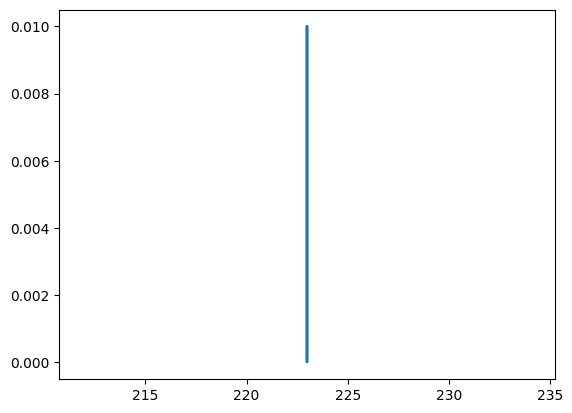

In [52]:
pred_long[pred_long["SKU"]=="sz21032"]["pred_qty"].plot()

In [38]:
import numpy as np

horizon = y_hat.shape[1]
preds = y_hat.detach().cpu().numpy()

frames = []
for h in range(horizon):
    tmp = pred_index.copy()
    tmp["time_idx"] = tmp["time_idx"] + h      # step h into the future
    tmp["pred_qty"] = preds[:, h]
    frames.append(tmp)

pred_long = pd.concat(frames, ignore_index=True)

# recover dates if you want them explicitly
pred_long["date"] = min_date + pd.to_timedelta(pred_long["time_idx"], unit="D")

# now join back to future_df (which has future time_idx per SKU)
future_with_preds = future_df.merge(
    pred_long[["SKU", "time_idx", "pred_qty"]],
    on=["SKU", "time_idx"],
    how="left",
)

# future_with_preds now has a 'pred_qty' column with your DeepAR forecast


In [39]:
future_with_preds

,date,tavg,prcp,tsun,is_holiday,SKU,sale_percent,month,day_of_week,mmdd,price_per_unit,time_idx,pred_qty
0,2025-11-24,4.10,5.80,0.0,no_holiday,9101dx,0.2,11,0,11-24,1295.228583,0,NaN
1,2025-11-24,4.10,5.80,0.0,no_holiday,9101fz,0.2,11,0,11-24,1119.547500,0,NaN
2,2025-11-24,4.10,5.80,0.0,no_holiday,9101sf,0.2,11,0,11-24,1468.438148,0,NaN
3,2025-11-24,4.10,5.80,0.0,no_holiday,9101ub,0.2,11,0,11-24,864.650000,0,NaN
4,2025-11-24,4.10,5.80,0.0,no_holiday,9102dx,0.2,11,0,11-24,1937.436548,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
22619,2026-03-04,6.25,0.05,234.0,no_holiday,sz21011,0.0,3,2,03-04,74.790000,100,NaN
22620,2026-03-04,6.25,0.05,234.0,no_holiday,sz21012,0.0,3,2,03-04,74.375417,100,NaN
22621,2026-03-04,6.25,0.05,234.0,no_holiday,sz21022,0.0,3,2,03-04,59.830000,100,NaN
22622,2026-03-04,6.25,0.05,234.0,no_holiday,sz21031,0.0,3,2,03-04,108.120556,100,NaN


In [ ]:
import lightning.pytorch as pl
from pytorch_forecasting import DeepAR
from pytorch_forecasting.metrics.distributions import NegativeBinomialDistributionLoss

import torch
torch.set_float32_matmul_precision('medium')

# create data loaders
train_dataloader = deep_ar_dataset.to_dataloader(train=True, batch_size=64, num_workers=8)

# set up the trainer
trainer = pl.Trainer(
    max_epochs=20,
    accelerator="auto",
    gradient_clip_val=0.1,
)

# configure DeepAR with a negative‑binomial likelihood
model = DeepAR.from_dataset(
    deep_ar_dataset,
    learning_rate=1e-3,
    hidden_size=64,
    rnn_layers=2,
    loss=NegativeBinomialDistributionLoss(),
)

# train the network
trainer.fit(model, train_dataloaders=train_dataloader)


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                   | Type                             | Params | Mode  | FLOPs
--------------------------------------------------------------------------------------------
0 | loss                   | NegativeBinomialDistributionLoss | 0      | train | 0    
1 | logging_metrics        | ModuleList                       | 0      | train | 0    
2 | embeddings             | MultiEmbedding                   | 7.5 K  | train | 0    
3 | rnn                    | LSTM                             | 63.5 K | train | 0    
4 | distribution_projector | Linear                           | 130    | train | 0    
---------------------------------------------------------

Training: |          | 0/? [00:00<?, ?it/s]

/home/roman/eleo/eleo-mind/packages/backend/.venv/lib/python3.11/site-packages/lightning/pytorch/loops/training_epoch_loop.py:500: ReduceLROnPlateau conditioned on metric val_loss which is not available but strict is set to `False`. Skipping learning rate update.
